In [1]:
%run shared_imports.py

In [2]:
engine = make_engine("settings.toml")
session = Session(engine)

In [3]:
query = select(Feedback.json, Feedback.datetime).filter(
    Feedback.key_name == 'job_preferences',
    Feedback.datetime >= datetime(2023, 7, 1))

In [4]:
df = pd.read_sql_query(query, session.connection())

In [5]:
def job_preferences(jobname):
    return lambda x: {pref: count for pref, count in x['data'][jobname].items() if pref in ('high', 'medium', 'low', 'never')}

In [6]:
df = df.join(pd.json_normalize(df.json.map(job_preferences('Captain')))).drop(['json'], axis=1)
df['dt'] = pd.to_datetime(df.datetime.dt.year.astype(str) + df.datetime.dt.month.astype(str), format='%Y%m')
df.drop(['datetime'], inplace=True, axis=1)

In [7]:
summed = df.groupby(['dt']).sum().astype(int)

In [9]:
cols = ['high', 'medium', 'low', 'never']
summed[cols] = summed[cols].div(summed[cols].sum(axis=1), axis=0).multiply(100)

In [10]:
summed

,high,medium,low,never
dt,,,,
2023-07-01,2.751355,5.676588,8.182469,83.389588
2023-08-01,3.652671,6.876381,6.863382,82.607565
2023-09-01,3.021252,5.617461,7.650775,83.710511
2023-10-01,2.310163,5.625194,10.877447,81.187196
2023-11-01,3.039404,4.781355,11.701105,80.478136
2023-12-01,3.386971,4.113678,8.642616,83.856735
2024-01-01,3.251039,6.502078,9.154241,81.092642
2024-02-01,3.614602,4.608019,10.053860,81.723519
2024-03-01,2.720178,5.228540,9.587514,82.463768


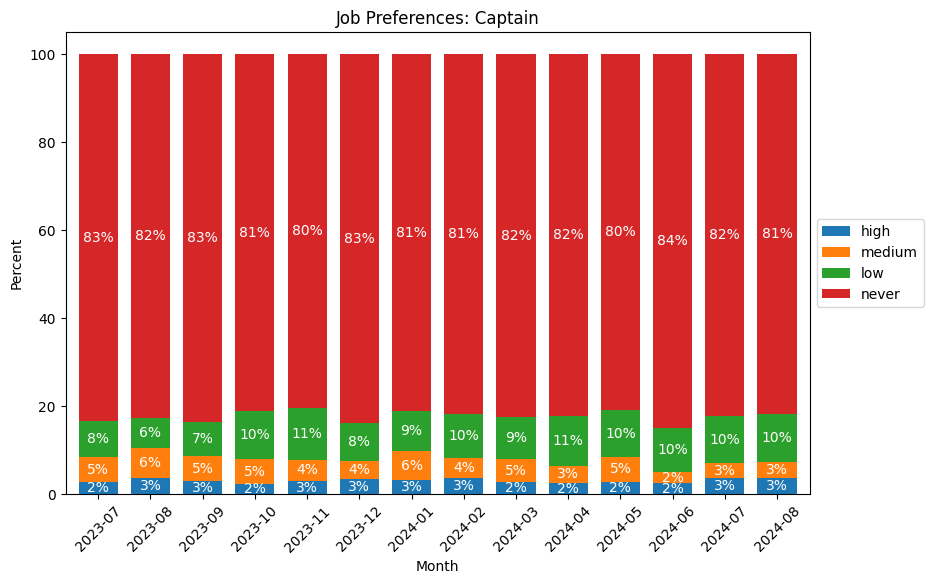

In [11]:
fig, ax = plt.subplots()
fig.set_size_inches(12, 6)

plot = summed.plot(kind='bar', stacked=True, ax=ax, width=0.75)
for c in ax.containers:
    labels = [f"{int(v.get_height())}%" if v.get_height() > 0 else '' for v in c]
    ax.bar_label(c, labels=labels, label_type='center', color='white')
ax.set_xticklabels([x.strftime("%Y-%m") for x in summed.index], rotation=45)
# plot.set(xlim=(date(2023, 7, 1), date(2024, 7, 1)))
plt.title("Job Preferences: Captain")
ax.set_xlabel('Month')
ax.set_ylabel('Percent')
box = ax.get_position()
ax.set_position([box.x0, box.y0, box.width * 0.8, box.height])

# Put a legend to the right of the current axis
ax.legend(loc='center left', bbox_to_anchor=(1, 0.5))
plt.savefig('vampire_subclass_percentage.png')

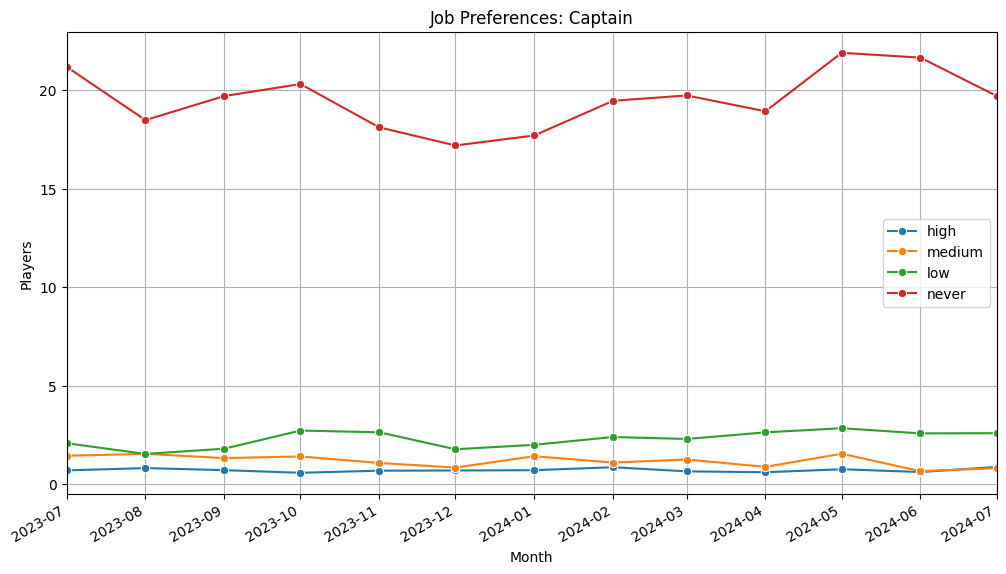

In [17]:
fig, ax = plt.subplots()
fig.set_size_inches(12, 6)
plot = sns.lineplot(
    data=df.groupby(['dt']).mean(),
    marker='o',
    linestyle='solid',
    dashes=False,
)
plot.set(xlim=(date(2023, 7, 1), date(2024, 7, 1)))
plot.set(title='Job Preferences: Captain')
plot.set(xlabel='Month', ylabel='Players')
months = mdates.MonthLocator(interval=1) 
ax.xaxis.set_major_locator(months)

for label in ax.get_xticklabels(which='major'):
    label.set(rotation=30, horizontalalignment='right')
ax.grid()
